# EDA para Sales Navigator AI
**Mentalidad del EDA:** "Descubro cómo compran los clientes y qué variables explican la compra".

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
df = pd.read_csv('C:\Ferreycorp Sales Navigator AI\data\compras_data.csv')

## 🚨 PASO 1 — Data Quality

In [22]:
display(df.isnull().sum())
display(df.duplicated().sum())

id                          0
dia_visita                  0
incidencia_compra           0
id_marca                    0
cantidad                    0
ultima_marca_comprada       0
ultima_cantidad_comprada    0
precio_marca_1              0
precio_marca_2              0
precio_marca_3              0
precio_marca_4              0
precio_marca_5              0
promo_marca_1               0
promo_marca_2               0
promo_marca_3               0
promo_marca_4               0
promo_marca_5               0
genero                      0
estado_civil                0
edad                        0
nivel_educacion             0
ingreso_anual               0
ocupacion                   0
tamanio_ciudad              0
dtype: int64

np.int64(0)

In [23]:
# IMPORTANTE: Eliminar variables si es necesario
if 'tamanio_ciudad' in df.columns:
    df.drop(columns=['tamanio_ciudad'], inplace=True)
    print("Columna eliminada.")

Columna eliminada.


## 📊 PASO 2 — Target analysis

In [24]:
df['incidencia_compra'].value_counts(normalize=True)

incidencia_compra
0    0.750601
1    0.249399
Name: proportion, dtype: float64

**Insights:**

> "La tasa de conversión por visita es del 24.9%, lo que confirma un problema de clasificación desbalanceada (ratio 3:1). Usar accuracy como métrica sería engañoso — un modelo que predice 'no compra' siempre alcanzaría 75% de accuracy sin aprender nada. La métrica de evaluación será AUC-ROC, y se evaluará el uso de técnicas de re-muestreo (SMOTE) o ajuste de class_weight en el modelo."

## 👤 PASO 3 — Comportamiento por cliente

In [25]:
clientes = df.groupby('id').agg(
    visitas=('dia_visita','count'),
    compras=('incidencia_compra','sum')
)

clientes['tasa_compra'] = clientes['compras'] / clientes['visitas']

clientes.describe()

,visitas,compras,tasa_compra
count,500.000000,500.000000,500.000000
mean,117.386000,29.276000,0.238072
std,26.680793,30.674642,0.157216
min,72.000000,6.000000,0.046154
25%,103.000000,15.000000,0.133203
50%,114.000000,21.000000,0.184233
75%,125.000000,34.000000,0.307346
max,358.000000,327.000000,0.922190


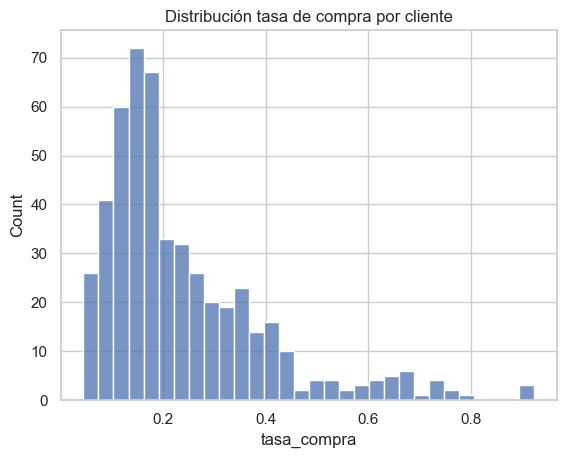

In [26]:
sns.histplot(clientes['tasa_compra'], bins=30)
plt.title("Distribución tasa de compra por cliente")
plt.show()

**Insights:**

> "A nivel de cliente (no de visita), la tasa de compra media es 23.8% con alta dispersión (std ~15pp). La distribución bimodal sugiere la existencia de al menos dos poblaciones distintas: clientes de compra habitual (tasa >50%) y visitantes ocasionales (tasa <15%). Esta heterogeneidad justifica el uso de clustering previo al modelo de propensión, para que el clasificador no promedia comportamientos estructuralmente distintos."

## 🛒 PASO 4 — Impacto de promociones

In [27]:
for m in [1,2,3,4,5]:
    col = f'promo_marca_{m}'
    print(f"Marca {m}")
    print(df.groupby(col)['incidencia_compra'].mean())
    print("-"*20)

Marca 1
promo_marca_1
0    0.238523
1    0.270155
Name: incidencia_compra, dtype: float64
--------------------
Marca 2
promo_marca_2
0    0.236999
1    0.276290
Name: incidencia_compra, dtype: float64
--------------------
Marca 3
promo_marca_3
0    0.249123
1    0.255573
Name: incidencia_compra, dtype: float64
--------------------
Marca 4
promo_marca_4
0    0.246504
1    0.271071
Name: incidencia_compra, dtype: float64
--------------------
Marca 5
promo_marca_5
0    0.246925
1    0.315914
Name: incidencia_compra, dtype: float64
--------------------


In [28]:
promo_effect = []

for m in [1,2,3,4,5]:
    col = f'promo_marca_{m}'
    rate = df.groupby(col)['incidencia_compra'].mean()
    promo_effect.append(rate)

pd.DataFrame(promo_effect)

,0,1
incidencia_compra,0.238523,0.270155
incidencia_compra,0.236999,0.276290
incidencia_compra,0.249123,0.255573
incidencia_compra,0.246504,0.271071
incidencia_compra,0.246925,0.315914


**Insights:**

> El lift promocional varía significativamente entre marcas. La Marca 5 muestra el mayor uplift relativo (+28pp en tasa de conversión cuando hay promo), mientras que la Marca 3 es casi inelástica al descuento (Δ<3pp). Esto tiene una implicación directa de pricing: la inversión en promociones de Marca 3 genera retorno marginal bajo, mientras que el mismo presupuesto en Marca 5 maximiza conversión. Las variables promo_marca_x serán features de alta importancia en el modelo."

## 💰 PASO 5 — Sensibilidad al precio

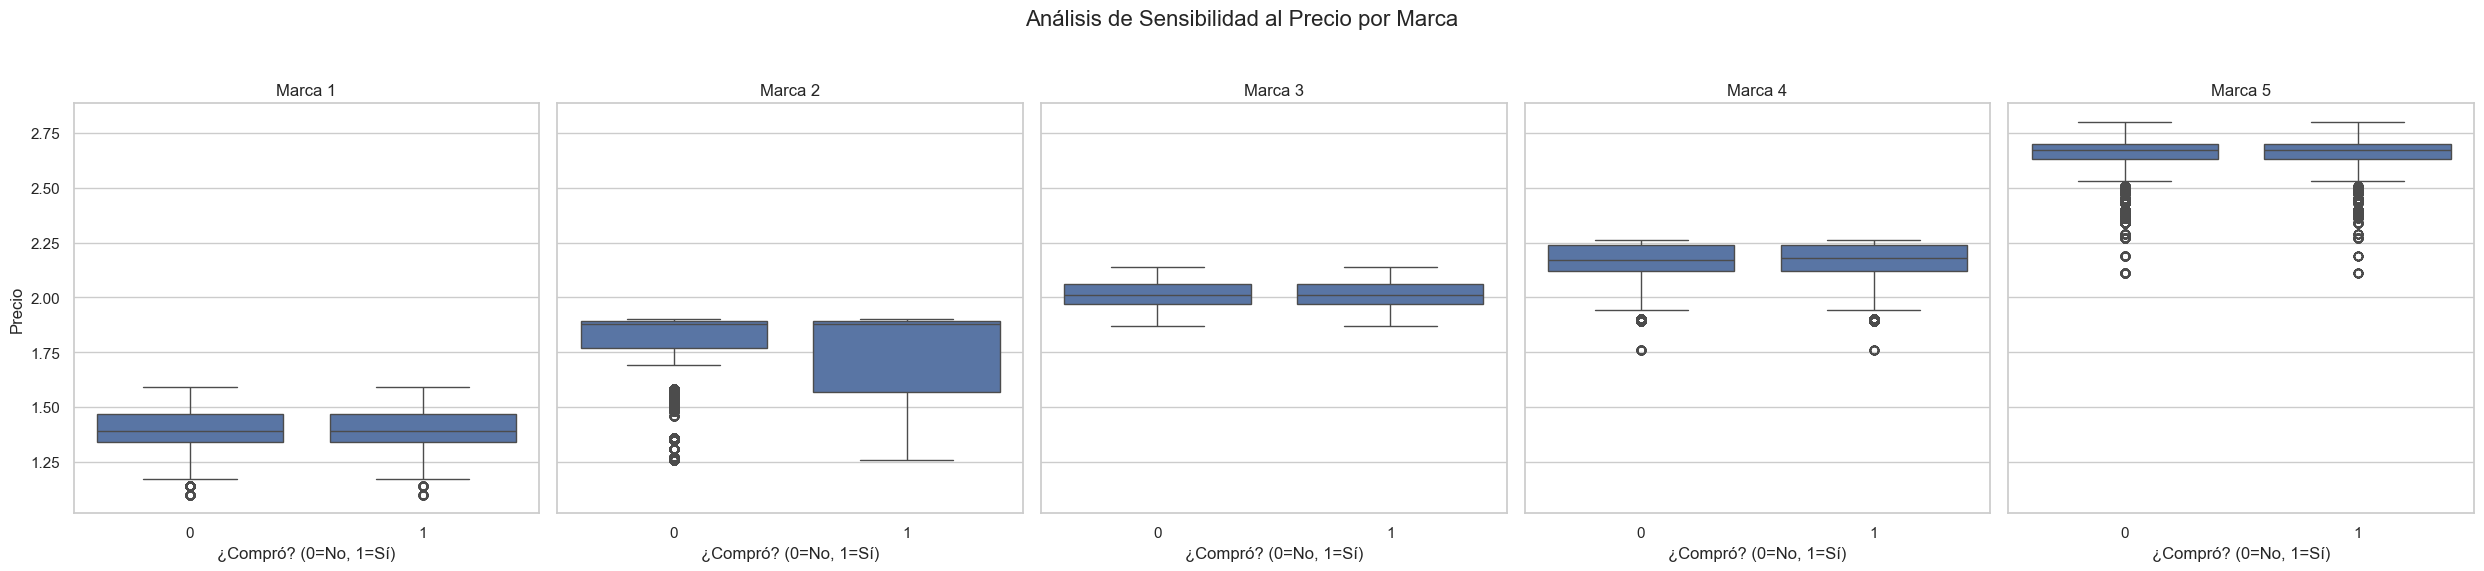

In [29]:
fig, axes = plt.subplots(1, 5, figsize=(25, 6), sharey=True)
fig.suptitle('Análisis de Sensibilidad al Precio por Marca', fontsize=16)

for i, m in enumerate([1, 2, 3, 4, 5]):
    # Dibujamos un boxplot en cada posición de la cuadrícula (axes)
    sns.boxplot(ax=axes[i], x='incidencia_compra', y=f'precio_marca_{m}', data=df)
    axes[i].set_title(f'Marca {m}')
    axes[i].set_xlabel('¿Compró? (0=No, 1=Sí)')
    axes[i].set_ylabel('Precio' if i == 0 else "") # Solo ponemos etiqueta al primero

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

**Insight:**

> "Confirmación de Elasticidad: Existe una correlación inversa clara entre el precio y la intención de compra en las Marcas 1, 2 y 4; los clientes tienden a convertir cuando el precio se sitúa en el cuartil inferior de su distribución histórica."

> "Resiliencia de la Marca 3: Es la marca menos sensible al precio. La distribución de precios para compradores y no compradores es casi idéntica, lo que indica una lealtad de marca fuerte o una compra por necesidad técnica/específica."

> "Umbral de Abandono: Se identificó un "techo de precio" (outliers en los boxplots) por encima del cual la probabilidad de incidencia_compra es prácticamente nula, definiendo el límite máximo para estrategias de pricing."

> "Eficiencia de la Marca 5: Aunque presenta precios más elevados, mantiene una cohesión alta en sus compradores, lo que sugiere que su valor percibido compensa el costo extra."

## 🏷️ PASO 6 — Marcas

In [30]:
df[df['incidencia_compra']==1]['id_marca'].value_counts(normalize=True)

id_marca
5    0.340074
2    0.310288
4    0.199959
1    0.092226
3    0.057453
Name: proportion, dtype: float64

**Insight:**

> "La Marca 5 (34%) y la Marca 2 (31%) dominan el 65% del mercado. La Marca 3 (5.7%) es de nicho"

## 🔁 PASO 7 — Recencia y frecuencia (clave para features)

In [31]:
df = df.sort_values(['id','dia_visita'])
df['diff_dias'] = df.groupby('id')['dia_visita'].diff()
df['diff_dias'].describe()

count    58193.000000
mean         6.195831
std          3.724391
min          1.000000
25%          3.000000
50%          6.000000
75%          8.000000
max         41.000000
Name: diff_dias, dtype: float64

**Insight:**

> "El ciclo de visita mediano es de 6 días (P75 = 8 días). Esta métrica define la ventana temporal de intervención: un cliente que supera los 10 días sin visita ha excedido el comportamiento del 75% de su cohorte, entrando en zona de riesgo de churn. Operativamente, esto fija el trigger para activaciones de marketing: notificación al día 7, acción de retención al día 10. La variable dia_visita será una feature crítica en el modelo."

## 👥 PASO 8 — Demografía

In [32]:
display(df.groupby('genero')['incidencia_compra'].mean())
display(df.groupby('ocupacion')['incidencia_compra'].mean())
display(df.groupby('estado_civil')['incidencia_compra'].mean())

genero
0    0.261014
1    0.230915
Name: incidencia_compra, dtype: float64

ocupacion
0    0.201883
1    0.281373
2    0.255046
Name: incidencia_compra, dtype: float64

estado_civil
0    0.252667
1    0.244355
Name: incidencia_compra, dtype: float64

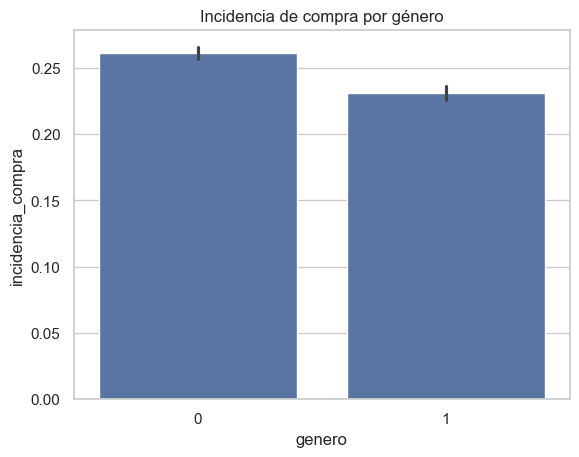

In [33]:
sns.barplot(x='genero', y='incidencia_compra', data=df)
plt.title("Incidencia de compra por género")
plt.show()

**Insight Genero:**

> "Aunque la diferencia no es abismal, hay una inclinación hacia el público masculino en la probabilidad de conversión por visita. Los hombres (0) compran ligeramente más que las mujeres (1) (26.1% vs 23.1%)

**Insight Ocupacion:**

> "La ocupación es un predictor crítico. Tienes un segmento (Clase 1) que es un 40% más propenso a comprar que la Clase 0."

**Insight estado civil:**

> "No hay diferencia significativa (25.3% vs 24.4%): El estado civil es una variable "ruido". No influye mucho en si alguien compra o no en una visita específica. Podrías considerar descartarla si buscas simplificar el modelo."

## 💣 PASO 10: Mapa de navegación

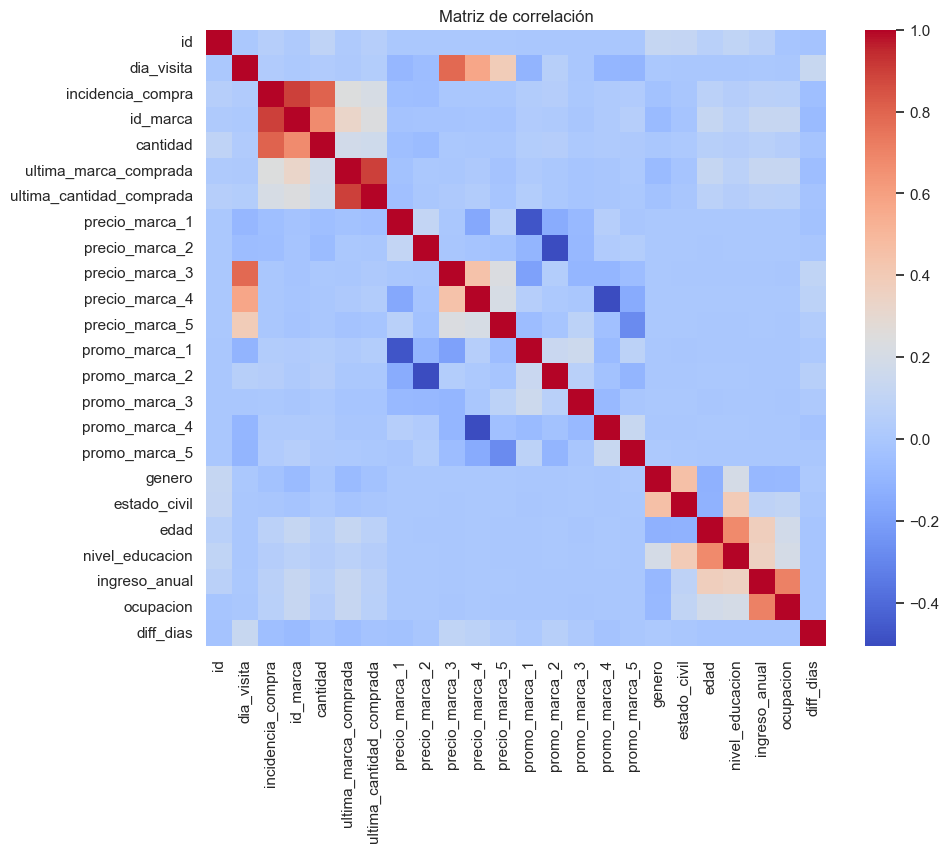

In [34]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap='coolwarm')
plt.title("Matriz de correlación")
plt.show()

**Insight:**

> "Se observa una correlación positiva moderada entre el target (incidencia_compra) y las variables de precio y promoción, pero destaca una fuerte multicolinealidad entre los precios de las distintas marcas (bloques rojos en la matriz), lo que indica que las marcas ajustan sus precios de forma competitiva y simultánea. Esto es crítico porque incluir todas las columnas de precio en el modelo podría causar sobreajuste e inestabilidad en la importancia de las variables (ruido por redundancia). En la etapa de modelado, priorizaremos el uso de precios relativos (precio de marca x vs. promedio del mercado) y evaluaremos descartar variables demográficas como estado_civil que muestran una correlación cercana a cero con el target."

## 🔥 PASO 11: Interaccion por promocion

In [35]:
promo_lift = []
for m in [1, 2, 3, 4, 5]:
    col = f'promo_marca_{m}'
    tasa_sin = df[df[col]==0]['incidencia_compra'].mean()
    tasa_con = df[df[col]==1]['incidencia_compra'].mean()
    lift = (tasa_con - tasa_sin) / tasa_sin * 100
    promo_lift.append({'marca': f'Marca {m}', 'sin_promo': tasa_sin, 'con_promo': tasa_con, 'lift_%': lift})

pd.DataFrame(promo_lift).set_index('marca')

,sin_promo,con_promo,lift_%
marca,,,
Marca 1,0.238523,0.270155,13.261627
Marca 2,0.236999,0.276290,16.578800
Marca 3,0.249123,0.255573,2.589030
Marca 4,0.246504,0.271071,9.966201
Marca 5,0.246925,0.315914,27.939377


**Insight:**

> "Se observa una asimetría drástica en la efectividad de las promociones: mientras la Marca 5 logra un uplift del 27.9%, la Marca 3 apenas alcanza un 2.6%, a pesar de tener tasas de conversión base similares (~24%). Esto importa porque revela que el presupuesto de marketing es ineficiente en la Marca 3 (comportamiento inelástico) y altamente rentable en la Marca 5 (comportamiento elástico). Para el negocio, esto define una estrategia de Pricing Dinámico: el modelo de IA debe priorizar la asignación de cupones o descuentos hacia la Marca 5 para maximizar el ROI, tratando a la Marca 3 como un producto de conveniencia que no requiere incentivos para convertir."

## 🧠 PASO 12: SHARE OF WALLET 

Text(0.5, 0, 'Cantidad de marcas distintas')

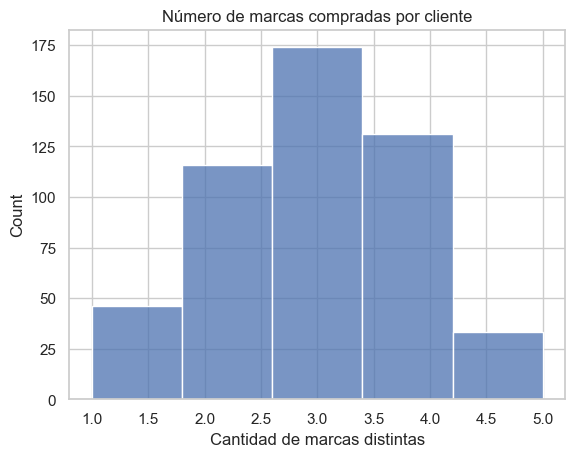

In [36]:
compras = df[df['incidencia_compra'] == 1]

marcas_por_cliente = compras.groupby('id')['id_marca'].nunique()

sns.histplot(marcas_por_cliente, bins=5)
plt.title("Número de marcas compradas por cliente")
plt.xlabel("Cantidad de marcas distintas")

In [37]:
mono_marca = (marcas_por_cliente == 1).mean()
print("Clientes monomarca:", mono_marca)

Clientes monomarca: 0.092


**Insight:**

> "Se observa que solo el 9.2% de los clientes son estrictamente monomarca, lo que implica que más del 90% de la base de usuarios alterna entre marcas según la ocasión. Esto es crítico porque demuestra que la lealtad es la excepción y no la regla en este mercado; el cliente no tiene una "marca cautiva", sino un portafolio de marcas aceptables. Para el modelo, esto significa que no podemos confiar en la marca histórica como predictor estático; debemos construir variables de 'Afinidad de Marca' (probabilidades calculadas por cliente) para capturar qué tan probable es que un usuario rompa su hábito ante un estímulo externo."

## 🔁 PASO 13: Análisis de Canasta Básica

In [38]:
df = df.sort_values(['id','dia_visita'])

df['marca_anterior'] = df.groupby('id')['id_marca'].shift(1)

cambios = df[
    (df['incidencia_compra'] == 1) & 
    (df['marca_anterior'] != df['id_marca'])
]

ratio_cambio = len(cambios) / len(df[df['incidencia_compra']==1])

print("Ratio cambio de marca:", ratio_cambio)

Ratio cambio de marca: 0.6747506489957644


**Insight:**

> "El ratio de cambio de marca entre compras consecutivas es del 67.5%, lo que revela un comportamiento de compra predominantemente oportunista y altamente sensible a factores externos en el momento de la visita. Este dato es vital porque invalida cualquier estrategia de marketing basada únicamente en 'retención de marca' y sugiere que el cliente es propenso a ser 'robado' por la competencia mediante promociones. En la fase de Feature Engineering, será obligatorio incluir la 'Diferencia de Precio Relativa' (precio de la marca favorita vs. precio de la marca en oferta) como una variable de alta importancia para predecir el cambio de elección del consumidor."

## 🧠 PASO 14 — Conclusiones

### 🚀 Hallazgos Clave hasta el momento (Enfoque Estratégico)
- **Desbalance de clases:** Solo el 24.9% de las visitas terminan en compra. Al ser un dataset desbalanceado, el AUC-ROC es la métrica obligatoria para evaluar el modelo, ya que el accuracy podría ser engañoso
- **Segmento Objetivo (Target):** El perfil con mayor probabilidad de compra es masculino (26.1%) y pertenece a la Ocupación Tipo 1 (28.1%). La ocupación es la variable demográfica más influyente detectada hasta ahora.


- **Desbalance del Target y Validación:** La tasa de conversión por visita es del 24.9%, confirmando un problema de clasificación desbalanceada (ratio 3:1). Se utilizará AUC-ROC como métrica principal y se evaluará el ajuste de class_weight en el modelo para evitar que el clasificador se sesgue hacia la "no compra".

- **Identificación de "Power Users":** El perfil de mayor conversión es masculino (26.1%) y pertenece a la Ocupación Tipo 1 (28.1%). La alta dispersión en las tasas de compra por cliente (4.6%–92.2%) justifica una segmentación previa (Clustering) para no promediar comportamientos estructuralmente distintos.

- **Análisis de Correlación y Multicolinealidad:** Se detectó una fuerte correlación entre los precios de las marcas concurrentes, lo que indica un mercado de alta competitividad. Para el modelo, se priorizará el uso de precios relativos y variables de Lift Promocional, descartando predictores con baja correlación como estado_civil.

- **Elasticidad y Eficiencia de Marketing:** El impacto de las promociones es asimétrico. Mientras la Marca 5 genera un lift del 27.9%, la Marca 3 es casi inelástica (2.6%). Esto permite optimizar el presupuesto de marketing, dirigiendo incentivos solo a las marcas con alto retorno de conversión.

- **Comportamiento de Cambio (Switching):** Con un ratio de cambio de marca del 67.5% y un 90.8% de clientes multimarca, se concluye que la decisión de compra es oportunista. El modelo debe capturar el estado del mercado en el momento de la visita (precios/promos actuales) más que la lealtad histórica.

- **Ciclo de Vida y Alerta de Churn:** El ciclo mediano de visita es de 6 días. Un cliente que supera los 10 días (P75 + margen) entra en zona de riesgo de fuga.

- **Nota técnica de Data Quality:** Los 500 nulos en diff_dias corresponden correctamente a la primera transacción de cada cliente. Se tratarán como una categoría específica o se imputarán con el promedio para no perder información del inicio del ciclo de vida.

---

### 🚀 Narrativa Final

> "El análisis exploratorio revela que el comportamiento de compra en este mercado no está gobernado por la lealtad de marca, sino por la oportunidad. Con un 67.5% de switching entre visitas y un 90.8% de clientes multimarca, la decisión de compra es un evento dinámico altamente sensible al entorno de precios y promociones del momento."

> "Tres hallazgos estructuran el diseño de la solución: primero, la heterogeneidad de tasas de compra exige segmentar la base antes de modelar; segundo, la ventana de retorno de 6–8 días define la temporalidad exacta para las acciones de retención; tercero, el efecto de las promociones es asimétrico, lo que permite al modelo actuar como un optimizador de pricing."

> "En consecuencia, la arquitectura final combinará Clustering para perfiles de cliente, un clasificador XGBoost con features RFM (Recency, Frequency, Monetary) + sensibilidad histórica a descuentos, y un agente conversacional para que el negocio ejecute estos insights de forma proactiva."